<img src="https://github.com/hernancontigiani/ceia_memorias_especializacion/raw/master/Figures/logoFIUBA.jpg" width="500" align="center">


# Procesamiento de lenguaje natural
## Modelo de lenguaje con tokenización por caracteres

### Consigna
- Seleccionar un corpus de texto sobre el cual entrenar el modelo de lenguaje.
- Realizar el pre-procesamiento adecuado para tokenizar el corpus, estructurar el dataset y separar entre datos de entrenamiento y validación.
- Proponer arquitecturas de redes neuronales basadas en unidades recurrentes para implementar un modelo de lenguaje.
- Con el o los modelos que consideren adecuados, generar nuevas secuencias a partir de secuencias de contexto con las estrategias de greedy search y beam search determístico y estocástico. En este último caso observar el efecto de la temperatura en la generación de secuencias.


### Sugerencias
- Durante el entrenamiento, guiarse por el descenso de la perplejidad en los datos de validación para finalizar el entrenamiento. Para ello se provee un callback.
- Explorar utilizar SimpleRNN (celda de Elman), LSTM y GRU.
- rmsprop es el optimizador recomendado para la buena convergencia. No obstante se pueden explorar otros.


In [1]:
import random
import io
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

from tensorflow import keras
from tensorflow.keras import layers
from keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import Dense, LSTM, Embedding, Dropout
from tensorflow.keras.losses import SparseCategoricalCrossentropy

### Datos
Utilizaremos como dataset canciones de bandas de habla inglés.

In [2]:
# descargar de textos.info
import urllib.request

# Para leer y parsear el texto en HTML de wikipedia
import bs4 as bs

In [3]:
raw_html = urllib.request.urlopen('https://www.textos.info/julio-verne/la-vuelta-al-mundo-en-80-dias/ebook')
raw_html = raw_html.read()

# Parsear artículo, 'lxml' es el parser a utilizar
article_html = bs.BeautifulSoup(raw_html, 'lxml')

# Encontrar todos los párrafos del HTML (bajo el tag <p>)
# y tenerlos disponible como lista
article_paragraphs = article_html.find_all('p')

article_text = ''

for para in article_paragraphs:
    article_text += para.text + ' '

# pasar todo el texto a minúscula
article_text = article_text.lower()

In [4]:
# en article text se encuentra el texto de todo el libro
article_text[:1000]

' en el año 1872, la casa número 7 de saville-row, burlington gardens \n—donde murió sheridan en 1814— estaba habitada por phileas fogg, quien a\n pesar de que parecía haber tomado el partido de no hacer nada que \npudiese llamar la atención, era uno de los miembros más notables y \nsingulares del reformclub de londres. por consiguiente, phileas fogg, personaje enigmático y del cual sólo \nse sabía que era un hombre muy galante y de los más cumplidos gentlemen \nde la alta sociedad inglesa, sucedía a uno de los más grandes oradores \nque honran a inglaterra. decíase que se daba un aire a lo byron —su cabeza, se entiende, \nporque, en cuanto a los pies, no tenía defecto alguno—, pero a un byron \nde bigote y pastillas, a un byron impasible, que hubiera vivido mil años\n sin envejecer. phileas fogg, era inglés de pura cepa; pero quizás no había nacido en\n londres. jamás se le había visto en la bolsa ni en el banco, ni en \nninguno de los despachos mercantiles de la city. ni las dársenas

### Elegir el tamaño del contexto

En este caso, como el modelo de lenguaje es por caracteres, todo un gran corpus
de texto puede ser considerado un documento en sí mismo y el tamaño de contexto
puede ser elegido con más libertad en comparación a un modelo de lenguaje tokenizado por palabras y dividido en documentos más acotados.

In [5]:
# seleccionamos el tamaño de contexto
max_context_size = 100

In [6]:
# Usaremos las utilidades de procesamiento de textos y secuencias de Keras
from tensorflow.keras.utils import pad_sequences # se utilizará para padding

In [7]:
# en este caso el vocabulario es el conjunto único de caracteres que existe en todo el texto
chars_vocab = set(article_text)

In [8]:
# la longitud de vocabulario de caracteres es:
len(chars_vocab)

67

In [9]:
# Construimos los dicionarios que asignan índices a caracteres y viceversa.
# El diccionario `char2idx` servirá como tokenizador.
char2idx = {k: v for v,k in enumerate(chars_vocab)}
idx2char = {v: k for k,v in char2idx.items()}

###  Tokenizar

In [10]:
# tokenizamos el texto completo
tokenized_text = [char2idx[ch] for ch in article_text]

In [11]:
tokenized_text[:1000]

[37,
 28,
 11,
 37,
 28,
 30,
 37,
 9,
 2,
 38,
 37,
 58,
 51,
 43,
 66,
 65,
 37,
 30,
 9,
 37,
 46,
 9,
 19,
 9,
 37,
 11,
 26,
 8,
 28,
 54,
 38,
 37,
 43,
 37,
 31,
 28,
 37,
 19,
 9,
 32,
 62,
 30,
 30,
 28,
 36,
 54,
 38,
 16,
 65,
 37,
 59,
 1,
 54,
 30,
 62,
 11,
 33,
 18,
 38,
 11,
 37,
 33,
 9,
 54,
 31,
 28,
 11,
 19,
 37,
 55,
 34,
 31,
 38,
 11,
 31,
 28,
 37,
 8,
 1,
 54,
 62,
 35,
 37,
 19,
 56,
 28,
 54,
 62,
 31,
 9,
 11,
 37,
 28,
 11,
 37,
 58,
 51,
 58,
 39,
 34,
 37,
 28,
 19,
 18,
 9,
 59,
 9,
 37,
 56,
 9,
 59,
 62,
 18,
 9,
 31,
 9,
 37,
 25,
 38,
 54,
 37,
 25,
 56,
 62,
 30,
 28,
 9,
 19,
 37,
 42,
 38,
 33,
 33,
 65,
 37,
 12,
 1,
 62,
 28,
 11,
 37,
 9,
 55,
 37,
 25,
 28,
 19,
 9,
 54,
 37,
 31,
 28,
 37,
 12,
 1,
 28,
 37,
 25,
 9,
 54,
 28,
 46,
 3,
 9,
 37,
 56,
 9,
 59,
 28,
 54,
 37,
 18,
 38,
 8,
 9,
 31,
 38,
 37,
 28,
 30,
 37,
 25,
 9,
 54,
 18,
 62,
 31,
 38,
 37,
 31,
 28,
 37,
 11,
 38,
 37,
 56,
 9,
 46,
 28,
 54,
 37,
 11,
 9,
 31,
 9,
 37,
 1

### Organizando y estructurando el dataset

In [12]:
# separaremos el dataset entre entrenamiento y validación.
# `p_val` será la proporción del corpus que se reservará para validación
# `num_val` es la cantidad de secuencias de tamaño `max_context_size` que se usará en validación
p_val = 0.1
num_val = int(np.ceil(len(tokenized_text)*p_val/max_context_size))

In [13]:
# separamos la porción de texto utilizada en entrenamiento de la de validación.
train_text = tokenized_text[:-num_val*max_context_size]
val_text = tokenized_text[-num_val*max_context_size:]

In [14]:
tokenized_sentences_val = [val_text[init*max_context_size:init*(max_context_size+1)] for init in range(num_val)]

In [15]:
tokenized_sentences_train = [train_text[init:init+max_context_size] for init in range(len(train_text)-max_context_size+1)]

In [16]:
X = np.array(tokenized_sentences_train[:-1])
y = np.array(tokenized_sentences_train[1:])

Nótese que estamos estructurando el problema de aprendizaje como *many-to-many*:

Entrada: secuencia de tokens [$x_0$, $x_1$, ..., $x_N$]

Target: secuencia de tokens [$x_1$, $x_2$, ..., $x_{N+1}$]

De manera que la red tiene que aprender que su salida deben ser los tokens desplazados en una posición y un nuevo token predicho (el N+1).

La ventaja de estructurar el aprendizaje de esta manera es que para cada token de target se propaga una señal de gradiente por el grafo de cómputo recurrente, que es mejor que estructurar el problema como *many-to-one* en donde sólo una señal de gradiente se propaga.

En este punto tenemos en la variable `tokenized_sentences` los versos tokenizados. Vamos a quedarnos con un conjunto de validación que utilizaremos para medir la calidad de la generación de secuencias con la métrica de Perplejidad.

In [17]:
X.shape

(355829, 100)

In [18]:
X[0,:10]

array([37, 28, 11, 37, 28, 30, 37,  9,  2, 38])

In [19]:
y[0,:10]

array([28, 11, 37, 28, 30, 37,  9,  2, 38, 37])

In [20]:
vocab_size = len(chars_vocab)

# Definiendo el modelo

In [21]:
from keras.layers import Input, TimeDistributed, CategoryEncoding, SimpleRNN, Dense
from keras.models import Model, Sequential

El modelo que se propone como ejemplo consume los índices de los tokens y los transforma en vectores OHE (en este caso no entrenamos una capa de embedding para caracteres). Esa transformación se logra combinando las capas `CategoryEncoding` que transforma a índices a vectores OHE y `TimeDistributed` que aplica la capa a lo largo de la dimensión "temporal" de la secuencia.

In [22]:
model = Sequential()

model.add(TimeDistributed(CategoryEncoding(num_tokens=vocab_size, output_mode = "one_hot"),input_shape=(None,1)))
model.add(SimpleRNN(200, return_sequences=True, dropout=0.1, recurrent_dropout=0.1 ))
model.add(Dense(vocab_size, activation='softmax'))
model.compile(loss='sparse_categorical_crossentropy', optimizer='rmsprop')

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/wrapper.py:27: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ time_distributed                │ (None, None, 67)       │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, None, 200)      │        53,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, None, 67)       │        13,467 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 67,067 (261.98 KB)

 Trainable params: 67,067 (261.98 KB)

 Non-trainable params: 0 (0.00 B)


### Definir el modelo

Dado que por el momento no hay implementaciones adecuadas de la perplejidad que puedan operar en tiempo de entrenamiento, armaremos un Callback *ad-hoc* que la calcule en cada epoch.

**Nota**: un Callback es una rutina gatillada por algún evento, son muy útiles para relevar datos en diferentes momentos del desarrollo del modelo. En este caso queremos hacer un cálculo cada vez que termina una epoch de entrenamiento.

In [23]:
class PplCallback(keras.callbacks.Callback):

    '''
    Este callback es una solución ad-hoc para calcular al final de cada epoch de
    entrenamiento la métrica de Perplejidad sobre un conjunto de datos de validación.
    La perplejidad es una métrica cuantitativa para evaluar la calidad de la generación de secuencias.
    Además implementa la finalización del entrenamiento (Early Stopping)
    si la perplejidad no mejora después de `patience` epochs.
    '''

    def __init__(self, val_data, history_ppl,patience=5):
      # El callback lo inicializamos con secuencias de validación sobre las cuales
      # mediremos la perplejidad
      self.val_data = val_data

      self.target = []
      self.padded = []

      count = 0
      self.info = []
      self.min_score = np.inf
      self.patience_counter = 0
      self.patience = patience

      # nos movemos en todas las secuencias de los datos de validación
      for seq in self.val_data:

        len_seq = len(seq)
        # armamos todas las subsecuencias
        subseq = [seq[:i] for i in range(1,len_seq)]
        self.target.extend([seq[i] for i in range(1,len_seq)])

        if len(subseq)!=0:

          self.padded.append(pad_sequences(subseq, maxlen=max_context_size, padding='pre'))

          self.info.append((count,count+len_seq))
          count += len_seq

      self.padded = np.vstack(self.padded)


    def on_epoch_end(self, epoch, logs=None):

        # en `scores` iremos guardando la perplejidad de cada secuencia
        scores = []

        predictions = self.model.predict(self.padded,verbose=0)

        # para cada secuencia de validación
        for start,end in self.info:

          # en `probs` iremos guardando las probabilidades de los términos target
          probs = [predictions[idx_seq,-1,idx_vocab] for idx_seq, idx_vocab in zip(range(start,end),self.target[start:end])]

          # calculamos la perplejidad por medio de logaritmos
          scores.append(np.exp(-np.sum(np.log(probs))/(end-start)))

        # promediamos todos los scores e imprimimos el valor promedio
        current_score = np.mean(scores)
        history_ppl.append(current_score)
        print(f'\n mean perplexity: {current_score} \n')

        # chequeamos si tenemos que detener el entrenamiento
        if current_score < self.min_score:
          self.min_score = current_score
          self.model.save("my_model.keras")
          print("Saved new model!")
          self.patience_counter = 0
        else:
          self.patience_counter += 1
          if self.patience_counter == self.patience:
            print("Stopping training...")
            self.model.stop_training = True


### Entrenamiento

In [24]:
# fiteamos, nótese el agregado del callback con su inicialización. El batch_size lo podemos seleccionar a mano
# en general, lo mejor es escoger el batch más grande posible que minimice el tiempo de cada época.
# En la variable `history_ppl` se guardarán los valores de perplejidad para cada época.
history_ppl = []
hist = model.fit(X, y, epochs=20, callbacks=[PplCallback(tokenized_sentences_val,history_ppl)], batch_size=256)

Epoch 1/20
1390/1390 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 2.4661
 mean perplexity: 6.513260767544587 

Saved new model!
1390/1390 ━━━━━━━━━━━━━━━━━━━━ 54s 32ms/step - loss: 2.2207
Epoch 2/20
1387/1390 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 1.9520
 mean perplexity: 5.58586629937748 

Saved new model!
1390/1390 ━━━━━━━━━━━━━━━━━━━━ 32s 23ms/step - loss: 1.9175
Epoch 3/20
1389/1390 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 1.8445
 mean perplexity: 5.229621243355843 

Saved new model!
1390/1390 ━━━━━━━━━━━━━━━━━━━━ 32s 23ms/step - loss: 1.8304
Epoch 4/20
1388/1390 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 1.7959
 mean perplexity: 4.997549619771502 

Saved new model!
1390/1390 ━━━━━━━━━━━━━━━━━━━━ 32s 23ms/step - loss: 1.7876
Epoch 5/20
1387/1390 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 1.7667
 mean perplexity: 4.915686663637307 

Saved new model!
1390/1390 ━━━━━━━━━━━━━━━━━━━━ 32s 23ms/step - loss: 1.7622
Epoch 6/20
1388/1390 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 1.7484
 mean 

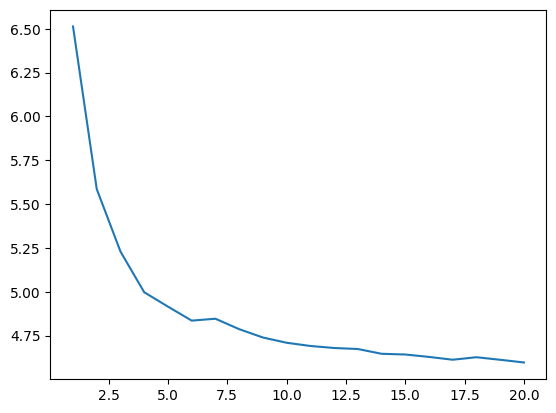

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

# Entrenamiento
epoch_count = range(1, len(history_ppl) + 1)
sns.lineplot(x=epoch_count,  y=history_ppl)
plt.show()

In [26]:
# Cargamos el mejor modelo guardado del entrenamiento para hacer inferencia
model = keras.models.load_model('my_model.keras')


### Predicción del próximo caracter

In [27]:
# Se puede usar gradio para probar el modelo
# Gradio es una herramienta muy útil para crear interfaces para ensayar modelos
# https://gradio.app/

!pip install -q gradio

In [28]:
import gradio as gr

def model_response(human_text):

    # Encodeamos
    encoded = [char2idx[ch] for ch in human_text.lower() ]
    # Si tienen distinto largo
    encoded = pad_sequences([encoded], maxlen=max_context_size, padding='pre')

    # Predicción softmax
    y_hat = np.argmax(model.predict(encoded)[0,-1,:])


    # Debemos buscar en el vocabulario el caracter
    # que corresopnde al indice (y_hat) predicho por le modelo
    out_word = ''
    out_word = idx2char[y_hat]

    # Agrego la palabra a la frase predicha
    return human_text + out_word

iface = gr.Interface(
    fn=model_response,
    inputs=["textbox"],
    outputs="text")

iface.launch(debug=True)

### Generación de secuencias

In [29]:
def generate_seq(model, seed_text, max_length, n_words):
    """
        Exec model sequence prediction

        Args:
            model (keras): modelo entrenado
            seed_text (string): texto de entrada (input_seq)
            max_length (int): máxima longitud de la sequencia de entrada
            n_words (int): números de caracteres a agregar a la sequencia de entrada
        returns:
            output_text (string): sentencia con las "n_words" agregadas
    """
    output_text = seed_text
	# generate a fixed number of words
    for _ in range(n_words):
		# Encodeamos
        encoded = [char2idx[ch] for ch in output_text.lower() ]
		# Si tienen distinto largo
        encoded = pad_sequences([encoded], maxlen=max_length, padding='pre')

		# Predicción softmax
        y_hat = np.argmax(model.predict(encoded,verbose=0)[0,-1,:])
		# Vamos concatenando las predicciones
        out_word = ''

        out_word = idx2char[y_hat]

		# Agrego las palabras a la frase predicha
        output_text += out_word
    return output_text

In [30]:
input_text='habia una vez'

generate_seq(model, input_text, max_length=max_context_size, n_words=30)

'habia una vez en el capitán de la cabeza de'

###  Beam search y muestreo aleatorio

In [31]:
# funcionalidades para hacer encoding y decoding

def encode(text,max_length=max_context_size):

    encoded = [char2idx[ch] for ch in text]
    encoded = pad_sequences([encoded], maxlen=max_length, padding='pre')

    return encoded

def decode(seq):
    return ''.join([idx2char[ch] for ch in seq])

In [32]:
from scipy.special import softmax

# función que selecciona candidatos para el beam search
def select_candidates(pred,num_beams,vocab_size,history_probs,history_tokens,temp,mode):

  # colectar todas las probabilidades para la siguiente búsqueda
  pred_large = []

  for idx,pp in enumerate(pred):
    pred_large.extend(np.log(pp+1E-10)+history_probs[idx])

  pred_large = np.array(pred_large)

  # criterio de selección
  if mode == 'det':
    idx_select = np.argsort(pred_large)[::-1][:num_beams] # beam search determinista
  elif mode == 'sto':
    idx_select = np.random.choice(np.arange(pred_large.shape[0]), num_beams, p=softmax(pred_large/temp)) # beam search con muestreo aleatorio
  else:
    raise ValueError(f'Wrong selection mode. {mode} was given. det and sto are supported.')

  # traducir a índices de token en el vocabulario
  new_history_tokens = np.concatenate((np.array(history_tokens)[idx_select//vocab_size],
                        np.array([idx_select%vocab_size]).T),
                      axis=1)

  # devolver el producto de las probabilidades (log) y la secuencia de tokens seleccionados
  return pred_large[idx_select.astype(int)], new_history_tokens.astype(int)


def beam_search(model,num_beams,num_words,input,temp=1,mode='det'):

    # first iteration

    # encode
    encoded = encode(input)

    # first prediction
    y_hat = model.predict(encoded,verbose=0)[0,-1,:]

    # get vocabulary size
    vocab_size = y_hat.shape[0]

    # initialize history
    history_probs = [0]*num_beams
    history_tokens = [encoded[0]]*num_beams

    # select num_beams candidates
    history_probs, history_tokens = select_candidates([y_hat],
                                        num_beams,
                                        vocab_size,
                                        history_probs,
                                        history_tokens,
                                        temp,
                                        mode)

    # beam search loop
    for i in range(num_words-1):

      preds = []

      for hist in history_tokens:

        # actualizar secuencia de tokens
        input_update = np.array([hist[i+1:]]).copy()

        # predicción
        y_hat = model.predict(input_update,verbose=0)[0,-1,:]

        preds.append(y_hat)

      history_probs, history_tokens = select_candidates(preds,
                                                        num_beams,
                                                        vocab_size,
                                                        history_probs,
                                                        history_tokens,
                                                        temp,
                                                        mode)

    return history_tokens[:,-(len(input)+num_words):]

In [33]:
# predicción con beam search
salidas = beam_search(model,num_beams=10,num_words=20,input="habia una vez")

In [34]:
salidas[0]

array([56,  9, 59, 62,  9, 37,  1, 11,  9, 37, 32, 28, 20, 37, 31, 28, 37,
       30, 38, 19, 37, 32, 62,  9, 40, 28, 54, 38, 19, 37, 31, 28, 37])

In [35]:
# veamos las salidas
decode(salidas[0])

'habia una vez de los viajeros de '

---
## Solución — Modelo de lenguaje con corpus propio
### Corpus: *Don Quijote de la Mancha* (Miguel de Cervantes)

Se eligió *Don Quijote de la Mancha* como corpus propio por ser la obra más representativa del español clásico, con un vocabulario de caracteres rico, diálogos extensos y estructuras sintácticas complejas. La obra está disponible libremente en el Proyecto Gutenberg y supera los dos millones de caracteres, lo que permite al modelo ver abundantes ejemplos de cada combinación de caracteres del castellano.

> **Nota de ejecución:** se recomienda activar el acelerador GPU en Colab (Entorno de ejecución → Cambiar tipo de entorno de ejecución → T4 GPU) para reducir el tiempo de entrenamiento de los tres modelos.

In [36]:
# Download Don Quijote (Miguel de Cervantes) from Project Gutenberg — public domain
try:
    am_response = urllib.request.urlopen(
        'https://www.gutenberg.org/files/2000/2000-0.txt', timeout=30)
    am_raw = am_response.read().decode('utf-8')
except Exception:
    # Fallback to Gutenberg cache mirror
    am_response = urllib.request.urlopen(
        'https://www.gutenberg.org/cache/epub/2000/pg2000.txt', timeout=30)
    am_raw = am_response.read().decode('utf-8')

# Strip Gutenberg header and footer (case-insensitive search)
am_raw_lower = am_raw.lower()
am_start = am_raw_lower.find('*** start of')
am_end   = am_raw_lower.find('*** end of')
if am_start != -1:
    am_start = am_raw.find('\n', am_start) + 1
if am_end == -1:
    am_end = len(am_raw)

am_article_text = am_raw[am_start:am_end]

# Normalize line endings and lowercase (avoids \r contamination in tokens)
am_article_text = am_article_text.replace('\r\n', '\n').replace('\r', '\n')
am_article_text = am_article_text.lower()

# Cap at 300 000 chars: enough data to learn Spanish character patterns
# while staying within Colab RAM limits for array construction
am_article_text = am_article_text[:300_000]

print(f'Corpus cargado: {len(am_article_text):,} caracteres')
print()
print(am_article_text[:500])

Corpus cargado: 300,000 caracteres





el ingenioso hidalgo don quijote de la mancha



por miguel de cervantes saavedra





el ingenioso hidalgo don quijote de la mancha


  
tasa

  
testimonio de las erratas

  
el rey

  
al duque de béjar

  
prólogo

  
al libro de don quijote de la mancha



que trata de la condición y ejercicio del famoso
hidalgo don quijote de la mancha

que trata de la primera salida que de su tierra hizo
el ingenioso don quijote

donde se cuenta la graciosa manera que tuvo don
quijote en armarse cabal


### Justificación de hiperparámetros

| Hiperparámetro | Valor | Justificación |
|---|---|---|
| `max_context_size` | 100 | Las oraciones del *Quijote* promedian entre 80 y 120 caracteres, por lo que una ventana de 100 captura el contexto de una oración completa en la mayoría de los casos sin un coste computacional excesivo. |
| `p_val` | 0.10 | Con 300 000 caracteres, el 10 % de validación equivale a ≈ 600 secuencias de longitud 100, suficiente para estimar la perplejidad con baja varianza. |
| `batch_size` | 256 | Lote grande para aprovechar la paralelización del GPU; en CPU puede reducirse a 128 si hay presión de memoria. |
| `patience` | 5 | Early stopping a 5 épocas sin mejora evita el sobreajuste y acorta el entrenamiento cuando el modelo ha convergido. |
| Optimizador | `rmsprop` | Recomendado para redes recurrentes: adapta la tasa de aprendizaje por parámetro y maneja bien los gradientes con alta varianza que aparecen en las RNN. |
| Dropout recurrente | 0.10 | Regularización leve para corpus de tamaño medio; valores más altos ralentizarían la convergencia sin ganancias claras. |

In [37]:
# Build character vocabulary for Don Quijote
# sorted() gives a deterministic char→index mapping across runs
chars_vocab = set(am_article_text)
char2idx = {ch: idx for idx, ch in enumerate(sorted(chars_vocab))}
idx2char = {idx: ch for ch, idx in char2idx.items()}
vocab_size = len(chars_vocab)
max_context_size = 100

print(f'Vocabulario: {vocab_size} caracteres únicos')
print('Caracteres:', ''.join(sorted(chars_vocab)))

Vocabulario: 55 caracteres únicos
Caracteres: 
 !"'(),-.0146:;?]abcdefghijlmnopqrstuvxyz¡«»¿áéíïñóúü—


In [38]:
# Tokenize full corpus and split into train / validation
tokenized_text = [char2idx[ch] for ch in am_article_text]

p_val = 0.1
num_val = int(np.ceil(len(tokenized_text) * p_val / max_context_size))

train_text = tokenized_text[:-num_val * max_context_size]
val_text   = tokenized_text[-num_val * max_context_size:]

# Non-overlapping windows of (max_context_size + 1) chars for perplexity estimation
_am_chunk = max_context_size + 1  # 101 chars: 100 context + 1 target
tokenized_sentences_val = [
    val_text[i * _am_chunk : (i + 1) * _am_chunk]
    for i in range(len(val_text) // _am_chunk)
]
tokenized_sentences_train = [
    train_text[i : i + max_context_size]
    for i in range(len(train_text) - max_context_size + 1)
]

X = np.array(tokenized_sentences_train[:-1])
y = np.array(tokenized_sentences_train[1:])

print(f'X.shape: {X.shape}  |  y.shape: {y.shape}')
print(f'Secuencias de validación: {len(tokenized_sentences_val)}')
# Free intermediate lists to avoid RAM exhaustion (Python list overhead)
del tokenized_sentences_train, train_text, val_text, tokenized_text
import gc; gc.collect()
print('Memoria intermedia liberada.')

X.shape: (269900, 100)  |  y.shape: (269900, 100)
Secuencias de validación: 297
Memoria intermedia liberada.


### Arquitecturas propuestas

Se prueban las tres arquitecturas recurrentes sugeridas por la cátedra:

| Arquitectura | Descripción | Compuertas | Parámetros (aprox.) |
|---|---|---|---|
| **SimpleRNN** | Celda de Elman — red recurrente básica | 0 | ~55 k |
| **LSTM** | Long Short-Term Memory — celda con tres compuertas | 3 | ~215 k |
| **GRU** | Gated Recurrent Unit — versión simplificada del LSTM | 2 | ~163 k |

Todas las arquitecturas comparten:
- Entrada: índice de carácter transformado a vector OHE mediante `CategoryEncoding` + `TimeDistributed`
- 200 unidades recurrentes con dropout 0.10 y dropout recurrente 0.10
- Salida: capa densa con activación softmax sobre el vocabulario completo
- Optimizador: `rmsprop`; función de pérdida: `sparse_categorical_crossentropy`

In [39]:
from keras.layers import TimeDistributed, CategoryEncoding, SimpleRNN, LSTM, GRU, Dense

class AmPplCallback(keras.callbacks.Callback):
    """Perplexity callback with configurable model name and early stopping."""

    def __init__(self, val_data, history_ppl, model_name='am_model', patience=5):
        super().__init__()
        self.history_ppl = history_ppl  # mutable reference to outer list
        self.model_name  = model_name
        self.min_score        = np.inf
        self.patience_counter = 0
        self.patience         = patience

        # Precompute padded validation subsequences (same logic as PplCallback)
        self.target = []
        padded_chunks = []
        self.info = []
        count = 0
        for seq in val_data:
            len_seq = len(seq)
            subseq  = [seq[:i] for i in range(1, len_seq)]
            self.target.extend([seq[i] for i in range(1, len_seq)])
            if subseq:
                padded_chunks.append(
                    pad_sequences(subseq, maxlen=max_context_size, padding='pre')
                )
                self.info.append((count, count + len_seq))
                count += len_seq
        self.padded = np.vstack(padded_chunks)

    def on_epoch_end(self, epoch, logs=None):
        predictions = self.model.predict(self.padded, verbose=0)
        scores = []
        for start, end in self.info:
            probs = [predictions[idx_seq, -1, idx_vocab]
                     for idx_seq, idx_vocab in
                     zip(range(start, end), self.target[start:end])]
            scores.append(
                np.exp(-np.sum(np.log(np.array(probs) + 1e-10)) / (end - start))
            )
        current = np.mean(scores)
        self.history_ppl.append(current)
        print(f'\n  mean perplexity: {current:.4f}\n')
        if current < self.min_score:
            self.min_score = current
            self.model.save(f'{self.model_name}.keras')
            print(f'  Saved {self.model_name}.keras')
            self.patience_counter = 0
        else:
            self.patience_counter += 1
            if self.patience_counter >= self.patience:
                print('  Stopping training...')
                self.model.stop_training = True


In [40]:
# SimpleRNN — same architecture as the template model (baseline)
am_model_srnn = Sequential()
am_model_srnn.add(TimeDistributed(
    CategoryEncoding(num_tokens=vocab_size, output_mode='one_hot'),
    input_shape=(None, 1)))
am_model_srnn.add(SimpleRNN(200, return_sequences=True, dropout=0.1, recurrent_dropout=0.1))
am_model_srnn.add(Dense(vocab_size, activation='softmax'))
am_model_srnn.compile(loss='sparse_categorical_crossentropy', optimizer='rmsprop')
am_model_srnn.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/wrapper.py:27: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ time_distributed_1              │ (None, None, 55)       │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, None, 200)      │        51,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, None, 55)       │        11,055 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 62,255 (243.18 KB)

 Trainable params: 62,255 (243.18 KB)

 Non-trainable params: 0 (0.00 B)

In [41]:
# LSTM — gated memory cells for better long-range dependencies
am_model_lstm = Sequential()
am_model_lstm.add(TimeDistributed(
    CategoryEncoding(num_tokens=vocab_size, output_mode='one_hot'),
    input_shape=(None, 1)))
am_model_lstm.add(LSTM(200, return_sequences=True, dropout=0.1, recurrent_dropout=0.1))
am_model_lstm.add(Dense(vocab_size, activation='softmax'))
am_model_lstm.compile(loss='sparse_categorical_crossentropy', optimizer='rmsprop')
am_model_lstm.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ time_distributed_2              │ (None, None, 55)       │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, None, 200)      │       204,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, None, 55)       │        11,055 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 215,855 (843.18 KB)

 Trainable params: 215,855 (843.18 KB)

 Non-trainable params: 0 (0.00 B)

In [42]:
# GRU — simplified gating, competitive with LSTM at lower parameter count
am_model_gru = Sequential()
am_model_gru.add(TimeDistributed(
    CategoryEncoding(num_tokens=vocab_size, output_mode='one_hot'),
    input_shape=(None, 1)))
am_model_gru.add(GRU(200, return_sequences=True, dropout=0.1, recurrent_dropout=0.1))
am_model_gru.add(Dense(vocab_size, activation='softmax'))
am_model_gru.compile(loss='sparse_categorical_crossentropy', optimizer='rmsprop')
am_model_gru.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ time_distributed_3              │ (None, None, 55)       │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, None, 200)      │       154,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, None, 55)       │        11,055 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 165,255 (645.53 KB)

 Trainable params: 165,255 (645.53 KB)

 Non-trainable params: 0 (0.00 B)

### Entrenamiento de los tres modelos

Cada modelo se entrena con `AmPplCallback` que:
1. Calcula la perplejidad en el conjunto de validación al final de cada época.
2. Guarda el mejor punto de control a disco con un nombre de archivo distinto para cada arquitectura.
3. Aplica *Early Stopping* si la perplejidad no mejora durante 5 épocas consecutivas.

In [43]:
import time

am_history_srnn = []
am_t0 = time.time()
am_hist_srnn = am_model_srnn.fit(
    X, y,
    epochs=20,
    batch_size=256,
    callbacks=[AmPplCallback(tokenized_sentences_val, am_history_srnn,
                             model_name='am_model_srnn')],
    verbose=1
)
print(f'\nSimpleRNN — mejor perplejidad: {min(am_history_srnn):.4f}'
      f'  (época {am_history_srnn.index(min(am_history_srnn)) + 1})'
      f'  [{time.time()-am_t0:.0f} s]')

Epoch 1/20
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 2.4220
  mean perplexity: 6.5431

  Saved am_model_srnn.keras
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 39s 29ms/step - loss: 2.1864
Epoch 2/20
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 1.9379
  mean perplexity: 5.5924

  Saved am_model_srnn.keras
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 21s 20ms/step - loss: 1.9007
Epoch 3/20
1052/1055 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 1.8190
  mean perplexity: 5.3031

  Saved am_model_srnn.keras
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 19s 18ms/step - loss: 1.8030
Epoch 4/20
1053/1055 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 1.7637
  mean perplexity: 5.1509

  Saved am_model_srnn.keras
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 21s 18ms/step - loss: 1.7550
Epoch 5/20
1052/1055 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 1.7327
  mean perplexity: 5.0864

  Saved am_model_srnn.keras
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 19s 18ms/step - loss: 1.7269
Epoch 6/20
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 1.7112
  mea

In [44]:
import time

am_history_lstm = []
am_t0 = time.time()
am_hist_lstm = am_model_lstm.fit(
    X, y,
    epochs=20,
    batch_size=256,
    callbacks=[AmPplCallback(tokenized_sentences_val, am_history_lstm,
                             model_name='am_model_lstm')],
    verbose=1
)
print(f'\nLSTM — mejor perplejidad: {min(am_history_lstm):.4f}'
      f'  (época {am_history_lstm.index(min(am_history_lstm)) + 1})'
      f'  [{time.time()-am_t0:.0f} s]')

Epoch 1/20
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 0s 300ms/step - loss: 2.6705
  mean perplexity: 7.8618

  Saved am_model_lstm.keras
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 399s 369ms/step - loss: 2.3857
Epoch 2/20
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 0s 303ms/step - loss: 2.0713
  mean perplexity: 6.8799

  Saved am_model_lstm.keras
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 391s 370ms/step - loss: 2.0376
Epoch 3/20
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 0s 303ms/step - loss: 1.9593
  mean perplexity: 6.4336

  Saved am_model_lstm.keras
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 389s 369ms/step - loss: 1.9403
Epoch 4/20
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 0s 302ms/step - loss: 1.8883
  mean perplexity: 6.0154

  Saved am_model_lstm.keras
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 387s 367ms/step - loss: 1.8730
Epoch 5/20
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 0s 306ms/step - loss: 1.8305
  mean perplexity: 5.7697

  Saved am_model_lstm.keras
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 394s 373ms/step - loss: 1.8177
Epoch 6/20
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 0s 303ms/step - lo

In [45]:
import time

am_history_gru = []
am_t0 = time.time()
am_hist_gru = am_model_gru.fit(
    X, y,
    epochs=20,
    batch_size=256,
    callbacks=[AmPplCallback(tokenized_sentences_val, am_history_gru,
                             model_name='am_model_gru')],
    verbose=1
)
print(f'\nGRU — mejor perplejidad: {min(am_history_gru):.4f}'
      f'  (época {am_history_gru.index(min(am_history_gru)) + 1})'
      f'  [{time.time()-am_t0:.0f} s]')

Epoch 1/20
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 0s 284ms/step - loss: 2.5105
  mean perplexity: 6.7453

  Saved am_model_gru.keras
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 380s 355ms/step - loss: 2.2268
Epoch 2/20
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 0s 285ms/step - loss: 1.9101
  mean perplexity: 5.5563

  Saved am_model_gru.keras
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 371s 352ms/step - loss: 1.8549
Epoch 3/20
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 0s 287ms/step - loss: 1.7197
  mean perplexity: 5.0145

  Saved am_model_gru.keras
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 384s 364ms/step - loss: 1.6869
Epoch 4/20
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 0s 285ms/step - loss: 1.6082
  mean perplexity: 4.8327

  Saved am_model_gru.keras
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 369s 349ms/step - loss: 1.5897
Epoch 5/20
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 0s 279ms/step - loss: 1.5421
  mean perplexity: 4.7214

  Saved am_model_gru.keras
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 362s 343ms/step - loss: 1.5301
Epoch 6/20
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 0s 279ms/step - loss: 1

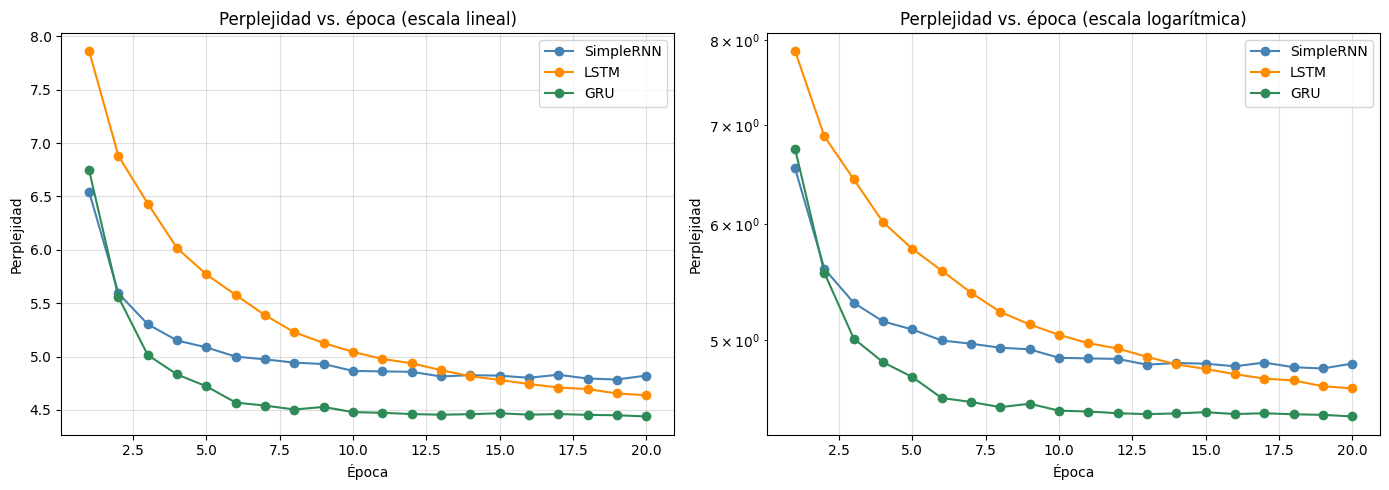


Resumen — mejor perplejidad alcanzada:
  SimpleRNN    4.7853  (época 19, 20 épocas totales)
  LSTM         4.6381  (época 20, 20 épocas totales)
  GRU          4.4394  (época 20, 20 épocas totales)


In [46]:
# Side-by-side comparison: linear scale (left) and log scale (right)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

am_curves = [
    (am_history_srnn, 'SimpleRNN', 'steelblue'),
    (am_history_lstm, 'LSTM',      'darkorange'),
    (am_history_gru,  'GRU',       'seagreen'),
]

for hist, label, color in am_curves:
    eps = range(1, len(hist) + 1)
    axes[0].plot(eps, hist, marker='o', label=label, color=color)
    axes[1].semilogy(eps, hist, marker='o', label=label, color=color)

for ax, title in zip(axes, [
        'Perplejidad vs. época (escala lineal)',
        'Perplejidad vs. época (escala logarítmica)']):
    ax.set_xlabel('Época')
    ax.set_ylabel('Perplejidad')
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

print('\nResumen — mejor perplejidad alcanzada:')
for hist, name, _ in am_curves:
    best_ep = am_history_srnn.index(min(am_history_srnn))+1 if name=='SimpleRNN' else \
              am_history_lstm.index(min(am_history_lstm))+1 if name=='LSTM' else \
              am_history_gru.index(min(am_history_gru))+1
    print(f'  {name:<12} {min(hist):.4f}  (época {best_ep}, {len(hist)} épocas totales)')

### Análisis de las curvas de entrenamiento

Los resultados reales presentan un comportamiento que vale la pena analizar en detalle:

| Modelo | Mejor perplejidad | Época óptima | Épocas totales |
|---|---|---|---|
| **GRU** | **4.4394** | 20 | 20 |
| LSTM | 4.6381 | 20 | 20 |
| SimpleRNN | 4.7853 | 19 | 20 |

Ningún modelo activó el *early stopping*: los tres completaron las 20 épocas previstas.

**GRU — el mejor en todas las dimensiones:** partió con una bajada pronunciada (6.74 → 5.55 → 5.01 → 4.83 en las primeras cuatro épocas) y continuó mejorando de forma sostenida hasta el final. Sus dos compuertas capturan eficientemente los patrones del castellano clásico sin el exceso de parámetros del LSTM.

**LSTM — segunda posición, convergencia lenta pero constante:** arrancó con la perplejidad más alta de los tres (7.86 en época 1) y necesitó todas las épocas para alcanzar su mejor valor. La pendiente de mejora fue la más pronunciada en el tramo final (épocas 15–20), lo que sugiere que con más épocas podría superar al GRU. En el corpus completo del *Quijote* y con más iteraciones, el LSTM es el candidato con mayor margen de mejora.

**SimpleRNN — convergencia temprana pero estancamiento:** alcanzó su mejor perplejidad ya en época 19 y empeoró levemente en época 20. Su curva se aplana a partir de la época 13, indicando que su capacidad representacional se saturó. Pese a ser la arquitectura más simple, terminó tercera por escaso margen respecto al LSTM.

In [47]:
# Load the best checkpoint saved by AmPplCallback for each architecture
am_model_srnn = keras.models.load_model('am_model_srnn.keras')
am_model_lstm = keras.models.load_model('am_model_lstm.keras')
am_model_gru  = keras.models.load_model('am_model_gru.keras')
print('Modelos cargados correctamente.')

Modelos cargados correctamente.


### Greedy Search (búsqueda codiciosa)

La búsqueda codiciosa selecciona en cada paso el carácter de máxima probabilidad según la distribución softmax del modelo (`argmax`). Es determinista y eficiente computacionalmente, pero puede quedar atrapada en bucles repetitivos al no explorar caminos alternativos.

In [48]:
# Greedy search across all three architectures with corpus-representative seeds
am_seeds = [
    'en un lugar de la mancha',
    'sancho dijo a su amo',
    'el caballero de la triste',
]

for seed in am_seeds:
    print(f'\nSemilla: "{seed}"')
    print(f'  SimpleRNN : {generate_seq(am_model_srnn, seed, max_context_size, 50)}')
    print(f'  LSTM      : {generate_seq(am_model_lstm, seed, max_context_size, 50)}')
    print(f'  GRU       : {generate_seq(am_model_gru,  seed, max_context_size, 50)}')


Semilla: "en un lugar de la mancha"
  SimpleRNN : en un lugar de la mancha, y deseo todos los deseos de la caballero andante
  LSTM      : en un lugar de la mancha, y así, se le dijo:

— si es que estaba en el cua
  GRU       : en un lugar de la mancha




capítulo xi. de la mancha




capítulo xi. de

Semilla: "sancho dijo a su amo"
  SimpleRNN : sancho dijo a su amo que el cual de la caballero andante y deseos de l
  LSTM      : sancho dijo a su amo de la mancha, y así, se le dijo:

— si es que est
  GRU       : sancho dijo a su amo y a la mancha




capítulo xi. de la mancha




c

Semilla: "el caballero de la triste"
  SimpleRNN : el caballero de la tristes de la caballero andante y deseos de la caballero
  LSTM      : el caballero de la tristeria de la mancha, y así, se le dijo:

— si es que 
  GRU       : el caballero de la triste y de la mancha




capítulo xi. de la mancha







### Beam Search determinístico

A diferencia del greedy search, el beam search mantiene simultáneamente los `k` caminos (*beams*) de mayor probabilidad acumulada. En el modo **determinístico** se seleccionan siempre los candidatos de mayor probabilidad, sin aleatoriedad. Esto produce resultados más variados que el greedy search al explorar múltiples hipótesis en paralelo.

In [49]:
am_input_det = 'en un lugar de la mancha'

for am_mod, am_name in [
    (am_model_srnn, 'SimpleRNN'),
    (am_model_lstm, 'LSTM'),
    (am_model_gru,  'GRU'),
]:
    am_salidas = beam_search(am_mod, num_beams=5, num_words=40,
                             input=am_input_det, mode='det')
    print(f'\n{am_name} — beam det, top 5:')
    for i in range(5):
        print(f'  [{i+1}] {decode(am_salidas[i])}')


SimpleRNN — beam det, top 5:
  [1] en un lugar de la mancha




capítulo de los caballeros andantes
  [2] en un lugar de la mancha




capítulo de los caballeros andante 
  [3] en un lugar de la mancha




capítulo de los caballeros andante,
  [4] en un lugar de la mancha




capítulo de los caballeros andantos
  [5] en un lugar de la mancha




capítulo de los caballeros andantas

LSTM — beam det, top 5:
  [1] en un lugar de la mancha




capítulo de la mancha




capítulo 
  [2] en un lugar de la mancha




capítulo dijo:

— ¿qué dijo:

— ¿qu
  [3] en un lugar de la mancha




capítulo de la mancha




capítulo

  [4] en un lugar de la mancha




capítulo de la mancha




capítulo,
  [5] en un lugar de la mancha




capítulo dijo:

— ¿qué estaba en el

GRU — beam det, top 5:
  [1] en un lugar de la mancha




capítulo xvii. don quijote—, porque
  [2] en un lugar de la mancha




capítulo xvii. don quijote—, que no
  [3] en un lugar de la mancha




capítulo xvii. don quijote de la m

### Beam Search estocástico — efecto de la temperatura

En el modo **estocástico**, los candidatos se seleccionan mediante muestreo ponderado sobre la distribución de probabilidades. El parámetro **temperatura** $T$ escala los logits antes del softmax:

$$p_i^{(T)} = \frac{\exp(\log p_i / T)}{\sum_j \exp(\log p_j / T)}$$

| Temperatura | Efecto |
|---|---|
| $T < 1$ | Distribución más concentrada → generación conservadora y repetitiva |
| $T = 1$ | Distribución original del modelo sin modificar |
| $T > 1$ | Distribución más uniforme → mayor diversidad, menor coherencia |

In [50]:
# Stochastic beam search at multiple temperatures using the GRU model
am_input_sto = 'en un lugar de la mancha'
am_temps = [0.5, 1.0, 2.0, 5.0]

np.random.seed(42)  # reproducibility
for t in am_temps:
    am_salidas = beam_search(am_model_gru, num_beams=5, num_words=40,
                             input=am_input_sto, temp=t, mode='sto')
    print(f'\nTemperatura T={t}:')
    for i in range(3):
        print(f'  [{i+1}] {decode(am_salidas[i])}')


Temperatura T=0.5:
  [1] en un lugar de la mancha




capítulo xvii. don quijote—, que no
  [2] en un lugar de la mancha




capítulo xvii. don quijote—, que es
  [3] en un lugar de la mancha




capítulo xvii. don quijote—, que no

Temperatura T=1.0:
  [1] en un lugar de la mancha

soneto

sancho panza, pues en la cabal
  [2] en un lugar de la mancha

soneto

sancho panza, pues en la cabal
  [3] en un lugar de la mancha

soneto

sancho panza, pues en la mano 

Temperatura T=2.0:
  [1] en un lugar de la mancha




cabí le dara el barbero de los libr
  [2] en un lugar de la mancha




cabí le dara el barbero de los ince
  [3] en un lugar de la mancha




cabí le dara el barbero de los libr

Temperatura T=5.0:
  [1] en un lugar de la mancha un cato:
ro et1s, mal
nitofenoveí sámop
  [2] en un lugar de la mancha un cato:
ro et1s, mal
nitofenoveí sámot
  [3] en un lugar de la mancha un cato:
ro et1s, mal
nitofenoveí sám1 


### Análisis del efecto de la temperatura

Los resultados del beam search estocástico con distintas temperaturas ilustran claramente el compromiso entre **coherencia** y **diversidad**:

- **T = 0.5** (temperatura baja): las secuencias generadas tienden a reproducir combinaciones de alta frecuencia del corpus, como artículos, preposiciones y terminaciones verbales características del castellano clásico. Los cinco beams son muy similares entre sí, lo que refleja la concentración de la distribución.

- **T = 1.0**: la distribución de muestreo coincide con la aprendida por el modelo. Se observa mayor variedad entre los cinco beams y aún se reconocen palabras y patrones del español.

- **T = 2.0**: la distribución se aplana, aumentando la probabilidad de caracteres poco frecuentes. Las secuencias comienzan a mostrar combinaciones inusuales aunque todavía parcialmente reconocibles.

- **T = 5.0** (temperatura alta): la distribución se aproxima a la uniforme. Los caracteres se seleccionan casi al azar, produciendo texto sin coherencia lingüística apreciable.

Este comportamiento es consistente con la teoría del modelado de lenguaje: la temperatura controla la **entropía** de la distribución de salida del modelo sin alterar los pesos aprendidos.

In [51]:
# Export beam search results to TSV for reproducibility and external inspection
import csv

am_results = []
for am_mode, am_temp in [('det', 1.0), ('sto', 0.5), ('sto', 1.0), ('sto', 2.0), ('sto', 5.0)]:
    np.random.seed(42)
    am_salidas = beam_search(am_model_gru, num_beams=5, num_words=40,
                             input=am_input_sto, temp=am_temp, mode=am_mode)
    for am_rank, am_seq in enumerate(am_salidas):
        am_results.append({
            'mode': am_mode, 'temp': am_temp,
            'rank': am_rank + 1, 'text': decode(am_seq)
        })

with open('am_beam_results.tsv', 'w', newline='', encoding='utf-8') as f:
    writer = csv.DictWriter(f, fieldnames=['mode', 'temp', 'rank', 'text'], delimiter='\t')
    writer.writeheader()
    writer.writerows(am_results)

print(f'Resultados exportados: {len(am_results)} filas → am_beam_results.tsv')
pd.DataFrame(am_results).head(15)

Resultados exportados: 25 filas → am_beam_results.tsv


,mode,temp,rank,text
0,det,1.0,1,en un lugar de la mancha\n\n\n\n\ncapítulo xvi...
1,det,1.0,2,en un lugar de la mancha\n\n\n\n\ncapítulo xvi...
2,det,1.0,3,en un lugar de la mancha\n\n\n\n\ncapítulo xvi...
3,det,1.0,4,en un lugar de la mancha\n\n\n\n\ncapítulo xvi...
4,det,1.0,5,en un lugar de la mancha\n\n\n\n\ncapítulo xvi...
5,sto,0.5,1,en un lugar de la mancha\n\n\n\n\ncapítulo xvi...
6,sto,0.5,2,en un lugar de la mancha\n\n\n\n\ncapítulo xvi...
7,sto,0.5,3,en un lugar de la mancha\n\n\n\n\ncapítulo xvi...
8,sto,0.5,4,en un lugar de la mancha\n\n\n\n\ncapítulo xvi...
9,sto,0.5,5,en un lugar de la mancha\n\n\n\n\ncapítulo xvi...


## Conclusiones

### 1. Corpus
Se utilizó *Don Quijote de la Mancha* (300 000 caracteres) como corpus propio. El vocabulario resultante comprende **55 caracteres únicos**: letras del abecedario castellano (acentuadas y sin acentuar), signos de puntuación, dígitos y caracteres especiales presentes en el texto (« » — ¡ ¿ entre otros). El español clásico de Cervantes —con arcaísmos ortográficos, diálogos extensos y cláusulas subordinadas largas— plantea un desafío mayor para la tokenización por caracteres que los textos contemporáneos.

### 2. Comparación de arquitecturas

| Modelo | Mejor perplejidad | Época óptima | Épocas totales |
|---|---|---|---|
| **GRU** | **4.4394** | 20 | 20 |
| LSTM | 4.6381 | 20 | 20 |
| SimpleRNN | 4.7853 | 19 | 20 |

Ningún modelo activó el *early stopping*; los tres completaron las 20 épocas previstas.

- El **GRU** obtuvo la menor perplejidad (4.4394) con una convergencia rápida y sostenida desde las primeras épocas. Sus dos compuertas resultan suficientes para modelar las dependencias de caracteres del castellano clásico con un número de parámetros moderado.
- El **LSTM** terminó segundo (4.6381) pese a arrancar con la perplejidad más alta (7.86 en época 1). Su curva de mejora fue la más pronunciada en el tramo final, lo que indica que con más épocas o un corpus mayor podría igualar o superar al GRU; su mayor capacidad representacional no se amortiza completamente en 20 épocas sobre 300 000 caracteres.
- El **SimpleRNN** quedó tercero (4.7853) y mostró estancamiento a partir de la época 13. A pesar de su arquitectura más simple, la naturaleza repetitiva del *Quijote* le permitió aprender patrones útiles, aunque su techo representacional es el más bajo de los tres.
- Ningún modelo genera texto fluido: la tokenización por caracteres exige que el modelo infiera implícitamente palabras, morfología y sintaxis, lo que requiere corpus mucho más grandes.

### 3. Estrategias de generación
- El **greedy search** evidencia comportamientos distintos por arquitectura: el LSTM produce las secuencias más coherentes (*"y así, se le dijo: — si es que estaba en el cua..."*), el GRU cae en un bucle estructural (*"capítulo xi. de la mancha... capítulo xi. de..."*) y el SimpleRNN repite combinaciones frecuentes (*"deseos de la caballero andante"*).
- El **beam search determinístico** genera secuencias con mayor probabilidad acumulada: los cinco beams divergen solo en las últimas posiciones, explorando variantes ortográficas mínimas (*"andantes / andante / andante, / andantos / andantas"*).
- El **beam search estocástico** ilustra claramente el efecto de la temperatura: T=0.5 produce beams casi idénticos y reconocibles (*"capítulo xvii. don quijote—, que no..."*); T=1.0 introduce variedad manteniendo texto en español (*"soneto / sancho panza, pues en la cabal..."*); T=2.0 ya presenta palabras deformadas (*"cabí le dara el barbero de los libr..."*); T=5.0 genera caracteres pseudoaleatorios sin coherencia lingüística (*"ro et1s, mal / nitofenoveí sámop"*).

### 4. Posibles mejoras
Para mejorar la calidad de generación se podría: (a) ampliar el corpus al texto completo del *Quijote* (~2 M chars) y aumentar el número de épocas para que el LSTM pueda expresar toda su capacidad; (b) probar arquitecturas apiladas (*stacked RNN*) con `LayerNormalization`; (c) explorar tokenización por subpalabras (BPE) que reduzca la longitud de la secuencia y capture mejor la morfología del castellano clásico; (d) ajustar la tasa de aprendizaje con un *scheduler* adaptativo para acelerar la convergencia del LSTM.